# PSI5123 - Aprendizagem de Máquina de Sinais de Áudio e Voz

## 1. Configuração Inicial

Primeiro, vamos importar as bibliotecas necessárias: `librosa` para manipulação de áudio, `numpy` para operações numéricas e `matplotlib` para visualização.

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

## 2. Segmentação: Processamento de Prazo Curto

Sinais de voz são **não-estacionários**; suas propriedades mudam ao longo do tempo. Para analisá-los, usamos o **processamento de curto prazo (short-time processing)**. Isso envolve dividir o sinal em segmentos curtos e aproximadamente estacionários, chamados de **quadros (frames)**.

Os segmentos geralmente se **sobrepõem** para garantir uma transição suave das características e evitar a perda de informações nos limites.


### 2.1. Exemplo Básico de Segmentação

Métodos de **processamento de curto prazo (*short-time processing*)** consistem em dividir o sinal em segmentos que são "isolados" e então processados.

Esses segmentos normalmente **se sobrepõem (*overlap*)** entre si.

#### Exemplo

Considere um vetor

$$
\mathbf{x} = [0, 1, 2, 3, 4, 5, 6]
$$

que precisa ser segmentado (*framed*) em três partes, com:

- **tamanho do frame** = 3  
- **hop length** (sobreposição entre frames) = 2  

O resultado da segmentação será: 
[ [0, 1, 2],  [2, 3, 4],  [4, 5, 6] ]


In [2]:
# Definir um vetor
x = np.array([0, 1, 2, 3, 4, 5, 6])
print(f"Sinal original: {x}")

Sinal original: [0 1 2 3 4 5 6]


In [3]:
# Definir parâmetros do quadro
frame_length = 3
hop_length = 2

# Usar a função de enquadramento do librosa
frames = librosa.util.frame(x, frame_length=frame_length, hop_length=hop_length)
print(f"\nResultado da segmentação (formato librosa):\n{frames}")

# No librosa, cada coluna é um quadro. Para obter os quadros como linhas, transponha.
print(f"\nResultado dda segmentação (quadros como linhas):\n{frames.T}")


Resultado da segmentação (formato librosa):
[[0 2 4]
 [1 3 5]
 [2 4 6]]

Resultado dda segmentação (quadros como linhas):
[[0 1 2]
 [2 3 4]
 [4 5 6]]


### 2.2. Lidando com o Comprimento do Sinal com Preenchimento (Padding)

Ao enquadrar, o último quadro pode não se alinhar perfeitamente com o final do sinal. O `librosa` não faz preenchimento por padrão, o que pode levar à perda de dados. Podemos utilizar a função `librosa.util.fix_length` para preencher o sinal com zeros, garantindo que todos os quadros estejam completos.

In [4]:
x = np.array([0, 1, 2, 3, 4, 5, 6, 7])
print(f"Sinal original: {x}")

# Enquadramento sem preenchimento (a última amostra '7' é perdida)
frames = librosa.util.frame(x, frame_length=frame_length, hop_length=hop_length)

Sinal original: [0 1 2 3 4 5 6 7]


In [5]:
frames

array([[0, 2, 4],
       [1, 3, 5],
       [2, 4, 6]])

In [6]:
# Corrigir o comprimento para um tamanho que garanta que todos os quadros estejam completos.
x_padded = librosa.util.fix_length(x, size=9)
print(f"\nSinal preenchido: {x_padded}")


Sinal preenchido: [0 1 2 3 4 5 6 7 0]


In [7]:
frames = librosa.util.frame(x_padded, frame_length=frame_length, hop_length=hop_length)
print(f"\nEnquadramento com preenchimento:\n{frames.T}")


Enquadramento com preenchimento:
[[0 1 2]
 [2 3 4]
 [4 5 6]
 [6 7 0]]


### 2.3. Indexação Centralizada (Centered Indexing)

É comum centralizar o índice da janela. Para conseguir isso, preenchemos o sinal simetricamente antes do enquadramento. Esta abordagem é comum em extratores de características do `librosa` (usando `center=True`).

**Exemplo:** Um vetor `x` = [0, 1, 2, 3, 4, 5, 6] com segmentação centralizada, tamanho de quadro 3 e salto 1.

O resultado esperado: `[[0 0 1], [0 1 2], [1 2 3], [2 3 4], [3 4 5], [4 5 6], [5 6 0]]`

In [8]:
x = np.array([0, 1, 2, 3, 4, 5, 6])
win_length = 3
hop_length = 1
print(f"Sinal original: {x}")

Sinal original: [0 1 2 3 4 5 6]


In [9]:
# Preencher simetricamente com zeros
padding = win_length // 2
x_pad = np.pad(x, (padding, padding), 'constant', constant_values=(0, 0))
print(f"Sinal preenchido para enquadramento centralizado: {x_pad}")

Sinal preenchido para enquadramento centralizado: [0 0 1 2 3 4 5 6 0]


In [10]:
# Enquadrar o sinal preenchido
frames = librosa.util.frame(x_pad, frame_length=win_length, hop_length=hop_length)
centered_frames = frames.T
print(f"\nQuadros centralizados (uma linha por quadro):\n{centered_frames}")


Quadros centralizados (uma linha por quadro):
[[0 0 1]
 [0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 0]]


In [11]:
# Calcular o número de quadros
n_frames = int(((len(x_pad) - (win_length - 1) - 1) / hop_length) + 1)
print(f"\nNúmero de quadros: {n_frames}")


Número de quadros: 7


**Exemplo:** Considere um vetor $ \mathbf{x} = [0, 1, 2, 3, 4, 5, 6]$ com segmentação centralizada (*centered segmentation*), tamanho do frame igual a 4 e hop length igual a 1. Neste caso, o sinal é preenchido com zeros (*zero padding*) nas bordas para permitir que os frames sejam centralizados. **Use centro à direita**. O resultado da segmentação será:

[[0 0 0 1], [0 0 1 2 ], [0 1 2 3], [1 2 3 4], [2 3 4 5 ], [3 4 5 6], [4 5 6 0], [5 6 0 0]]

In [12]:
x

array([0, 1, 2, 3, 4, 5, 6])

In [13]:
win_length = 4
hop_length = 1
x_pad = np.pad(x, (win_length//2, win_length//2), 'constant', constant_values=(0,0))

In [14]:
x_pad

array([0, 0, 0, 1, 2, 3, 4, 5, 6, 0, 0])

In [15]:
frames = librosa.util.frame(x_pad, frame_length = win_length, hop_length = hop_length)

In [16]:
frames.T

array([[0, 0, 0, 1],
       [0, 0, 1, 2],
       [0, 1, 2, 3],
       [1, 2, 3, 4],
       [2, 3, 4, 5],
       [3, 4, 5, 6],
       [4, 5, 6, 0],
       [5, 6, 0, 0]])

In [17]:
n_frames = int(((len(x_pad) - (win_length - 1) - 1) / hop_length) + 1)
n_frames

8

#### Framing audio data

In [23]:
x_had, sr = librosa.load('SA1.WAV', sr = 16000, mono = True)

In [24]:
x_had

array([ 3.0517578e-05, -3.0517578e-05,  6.1035156e-05, ...,
       -3.0517578e-05, -1.5258789e-04, -2.4414062e-04],
      shape=(46797,), dtype=float32)

In [25]:
x_had.shape

(46797,)

In [26]:
segment_duration = 20e-3
hop_duration = 10e-3 # 10ms/20ms = 50%

In [27]:
frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

In [28]:
frame_length

320

In [29]:
hop_length

160

In [30]:
x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))

In [31]:
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)

In [32]:
frames.shape

(320, 293)

### 3. Processamento de Voz no Domínio do Tempo

Após enquadrar o sinal, podemos calcular vários parâmetros no domínio do tempo para cada quadro. Esses parâmetros formam a base para distinguir diferentes tipos de sons da voz.

#### 3.1. Parâmetros Comuns de Curta Duração

- **Energia de Curta Duração (E):** Representa a potência do sinal em um quadro. Alta para sons vozeados, baixa para silêncio.
  $$E[k] = \frac{1}{N} \sum_{n=0}^{N-1} s^2[n]$$

- **Magnitude Média de Curta Duração (MA):** Uma alternativa mais simples à energia, menos sensível a grandes variações de amplitude.
  $$MA[k] = \frac{1}{N} \sum_{n=0}^{N-1} |s[n]|$$

- **Taxa de Cruzamento por Zero de Curta Duração (ZCR):** A taxa na qual o sinal muda de sinal. Alta para sons não vozeados (fricativos), baixa para sons vozeados.
  $$ZCR[k] = \frac{1}{2N} \sum_{n=1}^{N-1} |\text{sgn}(x[n]) - \text{sgn}(x[n-1])|$$

no qual $K$ é o número de segmentos e $N$ é o número de amostras de cada segmento.

### 4. Aplicações Práticas com o Arquivo de Áudio 'SA1.WAV'

Agora, vamos aplicar esses conceitos a um arquivo de áudio real. Usaremos o arquivo `SA1.WAV`, que contém a frase "She had your dark suit in greasy wash water all year."

In [34]:
# Carregar o arquivo de áudio
x_had, sr = librosa.load('SA1.WAV', sr=16000, mono=True)

#### 4.1. Exercício Resolvido: Cálculo da Magnitude Média (MA)

Abrir o arquivo monofônico *SA1.WAV* utilizando a biblioteca librosa com frequência de amostragem igual a 16 kHz.

Implementar uma função que realiza a **segmentação** do arquivo em **blocos de 20 ms** com sobreposição de **10 ms** (i.e., 50%) e calcule o somatório do valor médio absoluto de cada segmento, ($\text{MA}\left[ k \right]=\frac{1}{N}\sum\limits_{n=0}^{N-1}{|s\left[ n \right]|}$, para $k = 0, 1, \cdots, K - 1$, no qual $K$ é o número de segmentos e $N$ é o número de amostras de cada segmento). Considere índice centralizado e janelamento retangular. 

In [35]:
# Definir durações
segment_duration = 20e-3  # 20 ms
hop_duration = 10e-3       # 10 ms (50% de sobreposição)

# Converter tempo em número de amostras
frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

print(f"Comprimento do quadro (em amostras): {frame_length}")
print(f"Salto (em amostras): {hop_length}")

# Preenchimento para indexação centralizada
x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))

# Segmentar o sinal
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)
print(f"Forma da matriz de quadros (comprimento_quadro, num_quadros): {frames.shape}")

Comprimento do quadro (em amostras): 320
Salto (em amostras): 160
Forma da matriz de quadros (comprimento_quadro, num_quadros): (320, 293)


In [36]:
# Calcular a Magnitude Média para cada quadro
magnitude = np.mean(np.abs(frames), axis=0)

In [37]:
magnitude.shape

(293,)

In [38]:
# Criar um eixo de tempo para os quadros
t_frame = np.arange(magnitude.shape[0]) * hop_duration

In [39]:
t_frame

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.

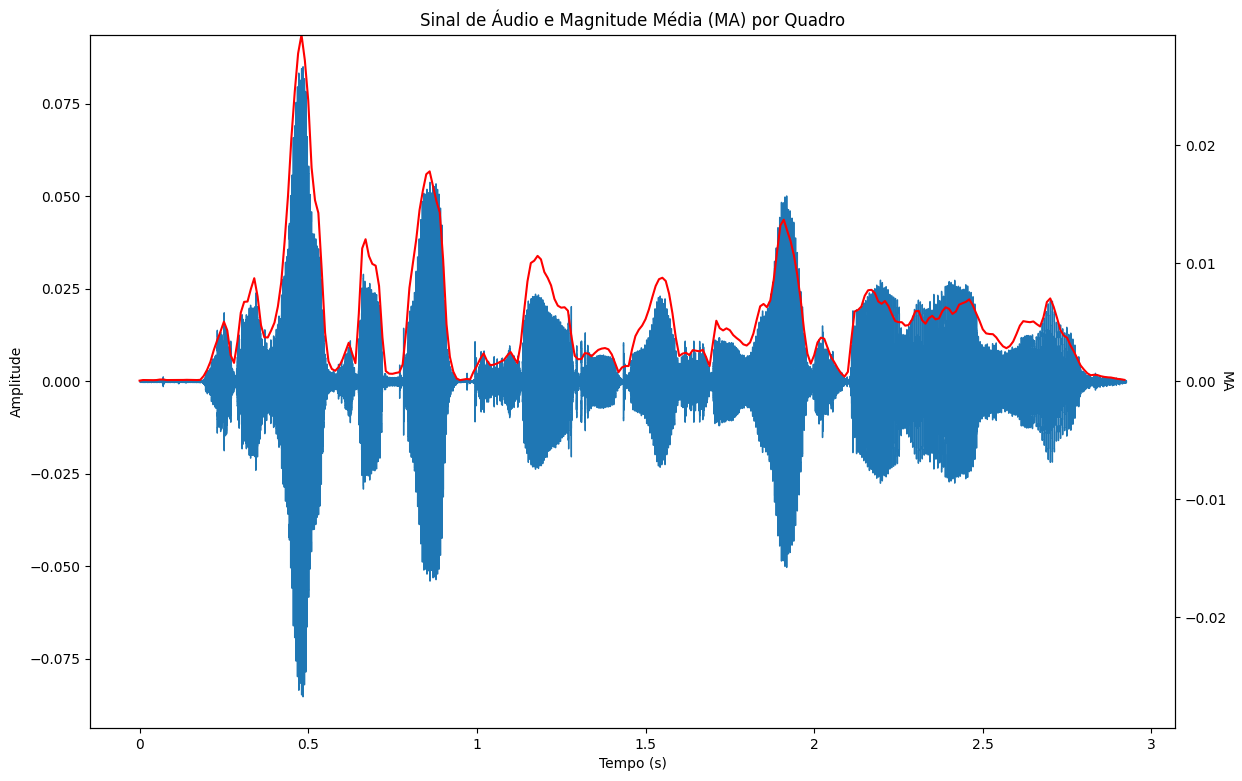

In [40]:
# Visualizar o sinal e a Magnitude Média
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame, magnitude, '-r', label='MA')
ax2.set_ylim(ymin=-np.max(magnitude), ymax=np.max(magnitude))
ax2.set_ylabel('MA', rotation=-90)
plt.title('Sinal de Áudio e Magnitude Média (MA) por Quadro')
plt.show()

#### 4.2. Variação: Tamanho de Quadro de 10ms

Agora, vamos repetir o cálculo da MA, mas com quadros de 10ms e sobreposição de 5ms (50%).

In [41]:
segment_duration = 10e-3
hop_duration = 5e-3

frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)
print(f"Forma da matriz de quadros: {frames.shape}")

magnitude = np.mean(np.abs(frames), axis=0)
t_frame = np.arange(magnitude.shape[0]) * hop_duration

Forma da matriz de quadros: (160, 585)


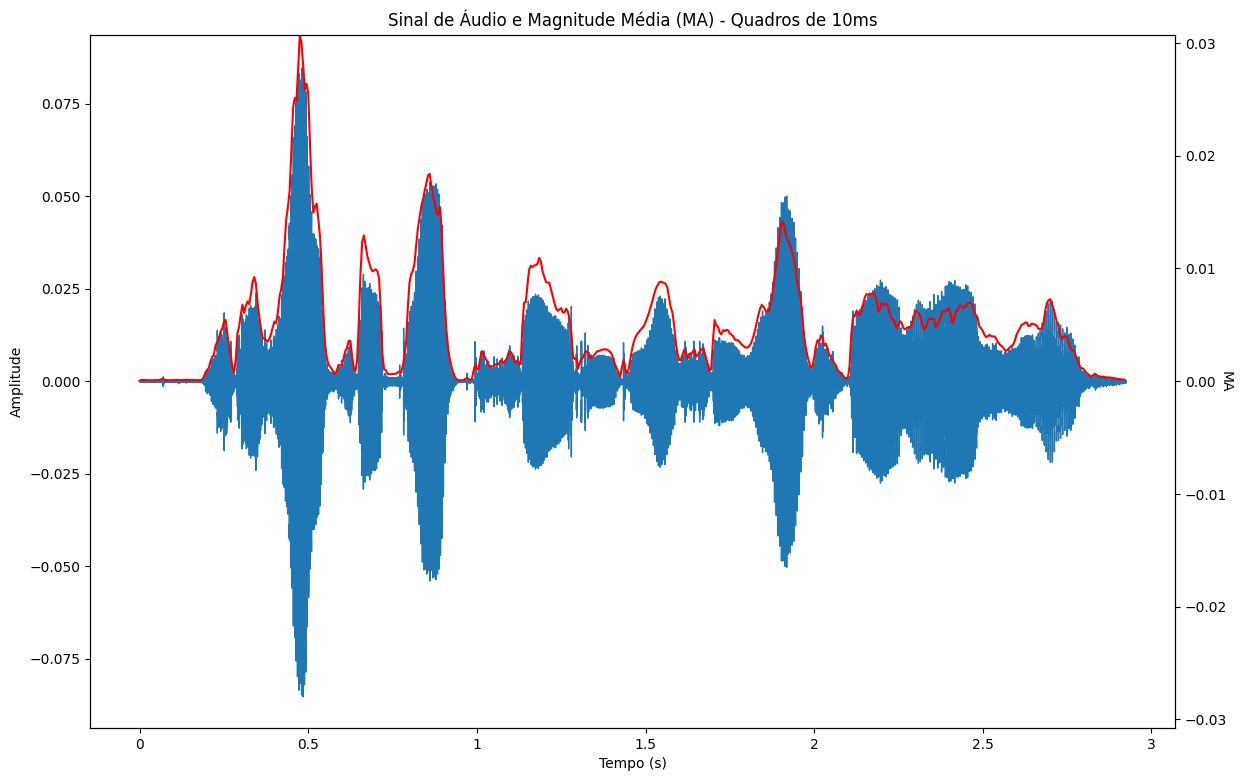

In [42]:
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame, magnitude, '-r', label='MA')
ax2.set_ylim(ymin=-np.max(magnitude), ymax=np.max(magnitude))
ax2.set_ylabel('MA', rotation=-90)
plt.title('Sinal de Áudio e Magnitude Média (MA) - Quadros de 10ms')
plt.show()

### 4.3. Exercício Resolvido: Cálculo da Energia (E)

Implementar uma função que realiza a **segmentação** do arquivo em **blocos de 20 ms** com sobreposição de **10 ms** (i.e., 50%) e calcule o somatório do valor da energia de cada segmento ($\text{E}\left[ k \right]=\frac{1}{N}\sum\limits_{n=0}^{N-1}{s^2\left[ n \right]}$, para $k = 0, 1, \cdots, K - 1$, no qual $K$ é o número de seguimentos e $N$ é o número de amostras de cada seguimento). Considere índice centralizado e janelamento retangular.

In [43]:
segment_duration = 20e-3
hop_duration = 10e-3

frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)

energy = np.mean(frames**2, axis=0)
t_frame = np.arange(energy.shape[0]) * hop_duration

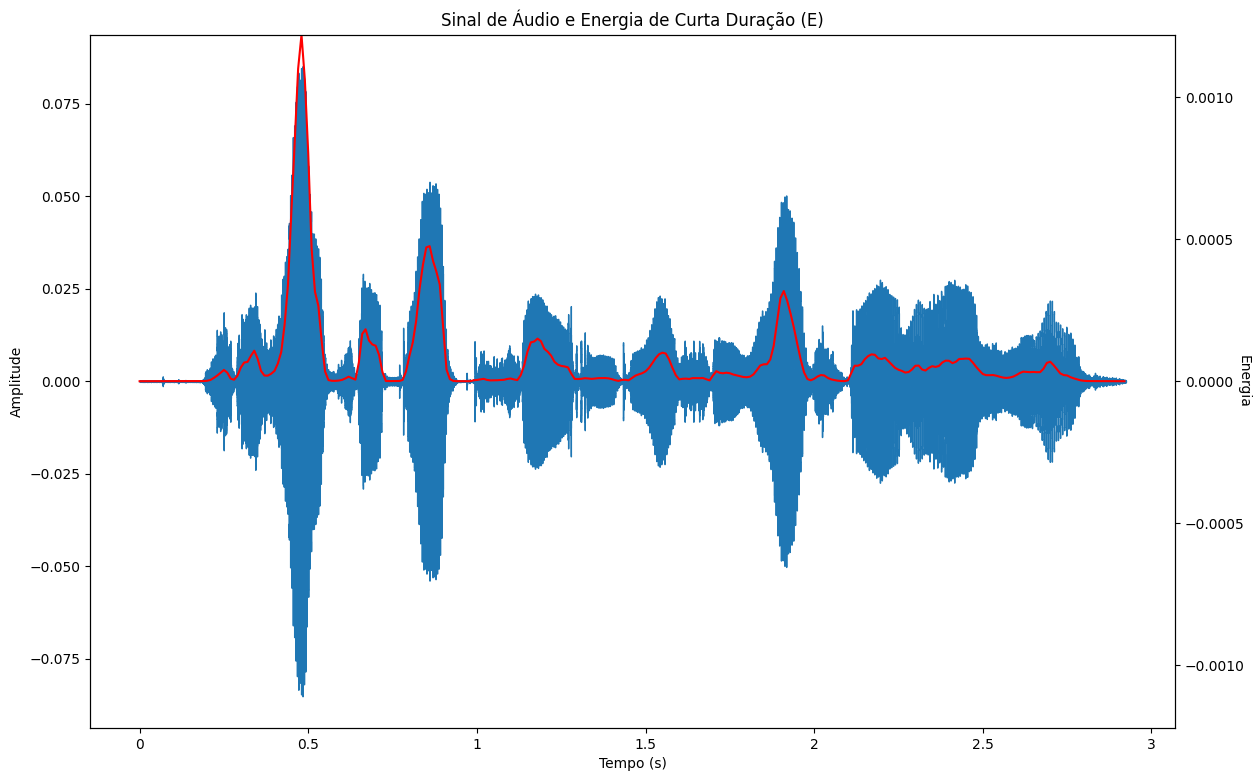

In [44]:
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame, energy, '-r', label='Energia')
ax2.set_ylim(ymin=-np.max(energy), ymax=np.max(energy))
ax2.set_ylabel('Energia', rotation=-90)
plt.title('Sinal de Áudio e Energia de Curta Duração (E)')
plt.show()

#### 4.4. Exercício Resolvido: Cálculo da Taxa de Cruzamento por Zero (ZCR)

Implementar uma função que realiza a **segmentação** do arquivo em **blocos de 20 ms** com sobreposição de **10 ms** (i.e., 50%) e calcule a taxa de cruzamento por zero de cada segmento ($\text{ZCR}\left[ k \right]=\frac{1}{2N}\sum\limits_{n=0}^{N-1}{|\text{sgn}[x[n]] - \text{sgn}[x[n-1]]|}$, para $k = 0, 1, \cdots, K - 1$, no qual $K$ é o número de seguimentos e $N$ é o número de amostras de cada seguimento). Considere índice centralizado e janelamento retangular.


A função sinal $\text{sgn}(\cdot)$ é definida como

$$
\text{sgn}(x) =
\begin{cases}
1, & x > 0 \\
0, & x = 0 \\
-1, & x < 0
\end{cases}
$$

Simplifique, para fins computacionais, para

$$
\text{sgn}(x) =
\begin{cases}
1, & x \ge 0 \\
-1, & x < 0
\end{cases}
$$

In [45]:
segment_duration = 20e-3
hop_duration = 10e-3

frame_length = int(segment_duration * sr)
hop_length = int(hop_duration * sr)

x_had_pad = np.pad(x_had, (frame_length//2, frame_length//2), 'constant', constant_values=(0,0))
frames = librosa.util.frame(x_had_pad, frame_length=frame_length, hop_length=hop_length)

In [46]:
# Implementação manual da ZCR
def sign_mod(x):
    return 1 if x >= 0 else -1

def zcr(frames):
    num_frames = frames.shape[1]
    frame_len = frames.shape[0]
    zcr = np.zeros(num_frames)
    for j in range(num_frames):
        for i in range(1, frame_len):
            zcr[j] += np.abs(sign_mod(frames[i, j]) - sign_mod(frames[i-1, j]))
    return zcr / (2 * frame_len)

zcr_manual_values = zcr(frames)
t_frame = np.arange(zcr_manual_values.shape[0]) * hop_duration

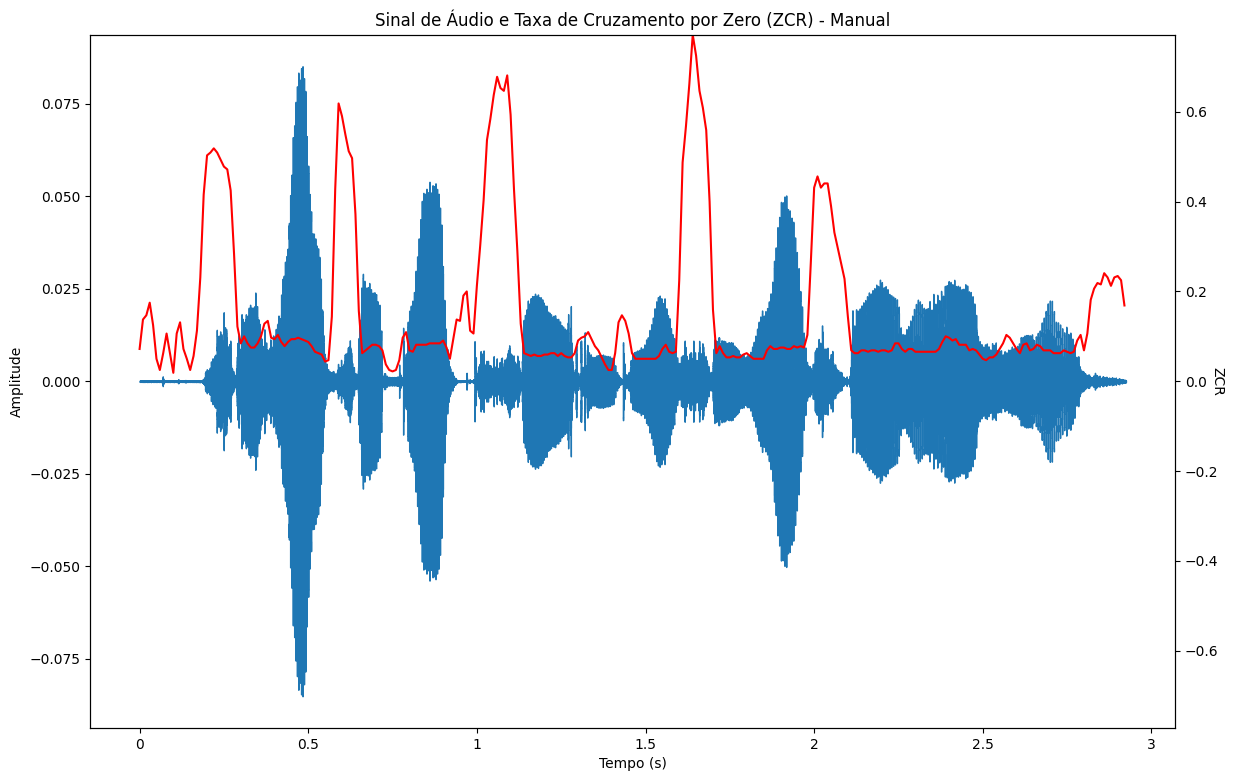

In [47]:
# Visualização da ZCR calculada manualmente
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame, zcr_manual_values, '-r', label='ZCR (manual)')
ax2.set_ylim(ymin=-np.max(zcr_manual_values), ymax=np.max(zcr_manual_values))
ax2.set_ylabel('ZCR', rotation=-90)
plt.title('Sinal de Áudio e Taxa de Cruzamento por Zero (ZCR) - Manual')
plt.show()

In [48]:
# Cálculo da ZCR usando a função do librosa
zcr_librosa = librosa.feature.zero_crossing_rate(y=x_had, frame_length=frame_length, hop_length=hop_length, center=True)
zcr_librosa = np.squeeze(zcr_librosa)
t_frame_librosa = np.arange(zcr_librosa.shape[0]) * hop_duration

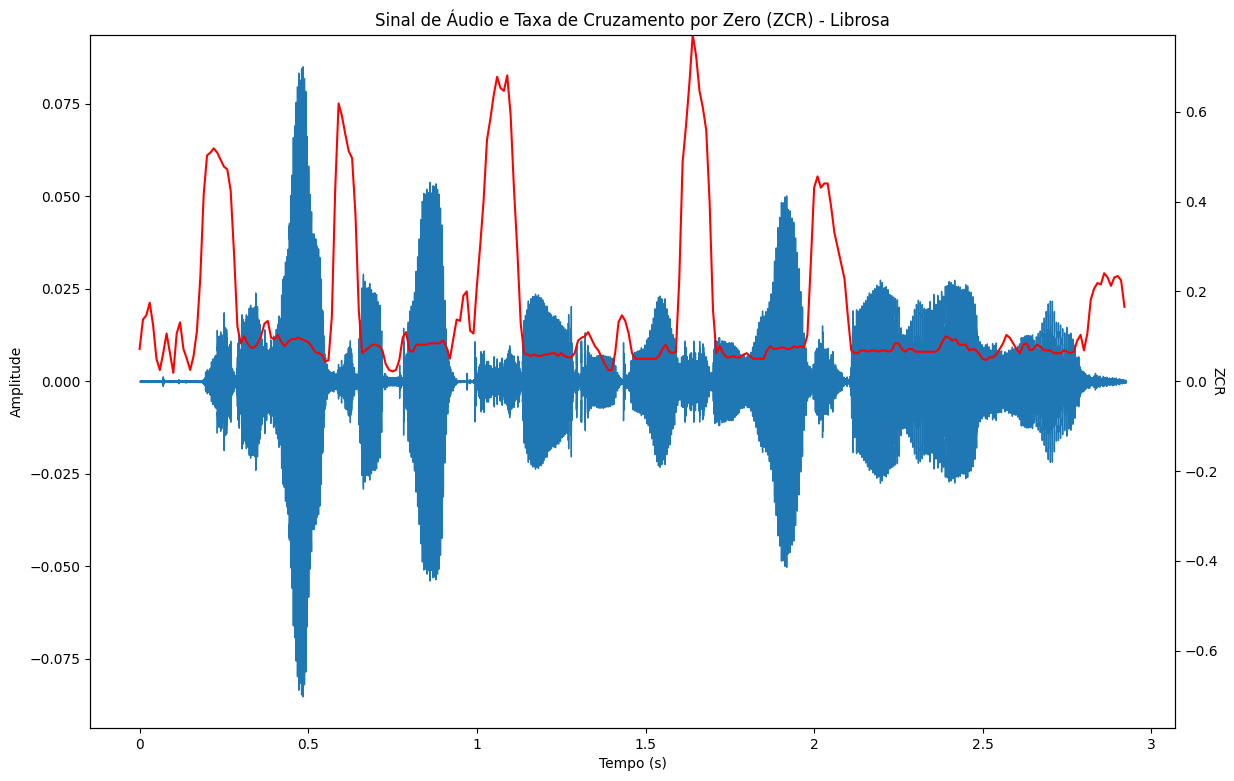

In [49]:
# Visualização da ZCR calculada pelo librosa
fig = plt.figure(figsize=(14, 9))
ax1 = fig.subplots()
ax2 = ax1.twinx()
librosa.display.waveshow(x_had, sr=sr, ax=ax1)
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel('Amplitude')
ax2.plot(t_frame_librosa, zcr_librosa, '-r', label='ZCR (librosa)')
ax2.set_ylim(ymin=-np.max(zcr_librosa), ymax=np.max(zcr_librosa))
ax2.set_ylabel('ZCR', rotation=-90)
plt.title('Sinal de Áudio e Taxa de Cruzamento por Zero (ZCR) - Librosa')
plt.show()

#### 4.5. Relação entre Energia, ZCR e Tipos de Sinal

**Objetivo:** Relacionar os valores de ZCR e energia para distinguir sons vozeados, não vozeados e silêncio.

*   **Sons Vozeados (ex: vogais):** Apresentam alta energia e baixa ZCR, devido à sua natureza periódica.
*   **Sons Não Vozeados (ex: fricativas como /s/, /f/):** Apresentam baixa energia e alta ZCR, devido à sua natureza aperiódica e ruidosa.
*   **Silêncio:** Apresenta energia muito baixa. A ZCR pode ser alta devido ao ruído de fundo, mas a energia é o indicador principal.

#### 4.6. Exercício Resolvido: Estimação da Frequência Fundamental (F0) por Autocorrelação

Um método para estimar a frequência fundamental*, F0, é pela função de autocorrelação. Considerando um segmento de $N$ amostras de um sinal de voz, $s[n]$, sua função de autocorrelação, $R[m]$, pode ser calculada por: $R\left[ m \right]=\sum\limits_{n=0}^{N-1-m}{s\left[ n \right]s\left[ n+m \right]} $ , para $m = 0, 1, \cdots, N - 1$. O pico principal na função de autocorrelação está em $m = 0$, localização do zerolag. A distância entre o primeiro máximo e o segundo máximo representa o período (lag) e, consequentemente, dividindo-se o valor da frequência de amostragem pelo lag se obtém uma estimativa do valor de F0. 

Implemente o algoritmo e utilize um segmento janelado de uma região vozeada do arquivo com o enunciado ``She had your dark suit...'' para estimar o valor de F0.

*Existem variações nos algoritmos de estimação, que podem ser utilizados para a solução deste exercício.

In [50]:
# Selecionar um quadro vozeado (ex: no tempo ~0.48s)
# (Assumindo que já temos 'frames' da célula anterior)
frame_index = 48  # Índice do quadro em t ~ 0.48s
s = frames[:, frame_index]
N = len(s) 


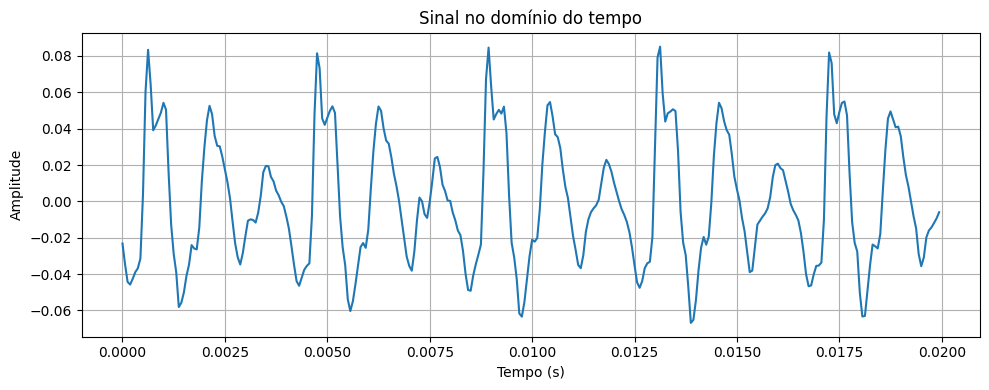

In [51]:
t = np.arange(N) / sr

plt.figure(figsize=(10,4))
plt.plot(t, s)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal no domínio do tempo")
plt.grid(True)

plt.tight_layout()
plt.show()

Considerando um segmento de $N$ amostras de um sinal de voz, $s[n]$, sua função de autocorrelação, $R[m]$, pode ser calculada por: $R\left[ m \right]=\sum\limits_{n=0}^{N-1-m}{s\left[ n \right]s\left[ n+m \right]} $ , para $m = 0, 1, \cdots, N - 1$. 

In [ ]:
# Implementação manual da autocorrelação
R = np.zeros(N)
for m in range(N):
    for n in range(N - m):
        R[m] += s[n] * s[n + m]

In [ ]:
# Função do librosa para comparação
R_lib = librosa.autocorrelate(s)

In [ ]:
# Visualizar a autocorrelação
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(R)
plt.title('Autocorrelação - Manual')
plt.xlabel('Lag (amostras)')
plt.ylabel('R[m]')

plt.subplot(1, 2, 2)
plt.plot(R_lib)
plt.title('Autocorrelação - Librosa')
plt.xlabel('Lag (amostras)')
plt.ylabel('R[m]')
plt.tight_layout()
plt.show()

In [ ]:
# Encontrar os picos da autocorrelação
from scipy.signal import find_peaks

peaks, _ = find_peaks(R, height=0)  # Encontrar todos os picos positivos
print(f"Índices dos picos encontrados: {peaks}")

In [ ]:
# Visualizar a autocorrelação com os picos marcados
plt.figure(figsize=(10, 4))
plt.plot(R)
plt.plot(peaks, R[peaks], 'x', label='Picos')
plt.title('Autocorrelação com Picos')
plt.xlabel('Lag (amostras)')
plt.ylabel('R[m]')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# O segundo pico significativo (ignorando o de lag 0) é o pico no lag 67.
lag = 67
f0 = sr/lag
print(f"Frequência fundamental estimada (F0): {f0:.2f} Hz")